In [ ]:
import os
from pathlib import Path

# Make relative paths (media/, layouts/) resolve the same way whether
# `marimo edit` is launched from the repo root or from this directory,
# and no-op harmlessly under the WASM/Pyodide export.
if "__file__" in globals() and __file__:
    try:
        os.chdir(Path(__file__).resolve().parent)
    except OSError:
        pass

import marimo as mo

# Ensemble methods

## Introduction

- In this lecture we will cover two complementary ensemble strategies: **parallel averaging** and **sequential additive fitting**.
- We will cover:
    - Recap: decision trees, and why a single tree is unstable
    - Bagging and random forests
    - Boosting: AdaBoost, derived from the exponential loss
    - Outlook: gradient boosting

## Two complementary ensemble strategies\n\nEnsemble learning improves a predictor by **combining several predictors**, but there are two fundamentally different ways to do it.\n\n| | **Parallel ensembles** | **Sequential ensembles** |\n|---|---|---|\n| **Core idea** | Fit many learners independently, then average/vote | Add learners one at a time, each improving the current ensemble |\n| **Main mechanism in this lecture** | Reduce variance by averaging; reduce correlation between learners | Build an additive model stage by stage, focusing on current errors / loss |\n| **Path** | **Bagging → Random Forest** | **AdaBoost → Gradient Boosting** |\n| **Mental model** | “Many noisy opinions, averaged” | “A sequence of corrections” |\n\n### Keep this map in mind\n\n- **Bagging / Random Forest:** learners can be trained independently (parallel).\n- **Boosting:** learner $m$ depends on the ensemble built in rounds $1,\dots,m-1$ (sequential).\n- The rest of the lecture explains *why* these two strategies work and how their mathematics differ.\n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

## Recap: decision trees

- Greedy, recursive partitioning of the feature space
- Split on the (feature, threshold) that most reduces impurity
- Deep tree: low bias, high variance
- Shallow tree: high bias, low variance
- Question: can we keep the low bias and reduce the variance?

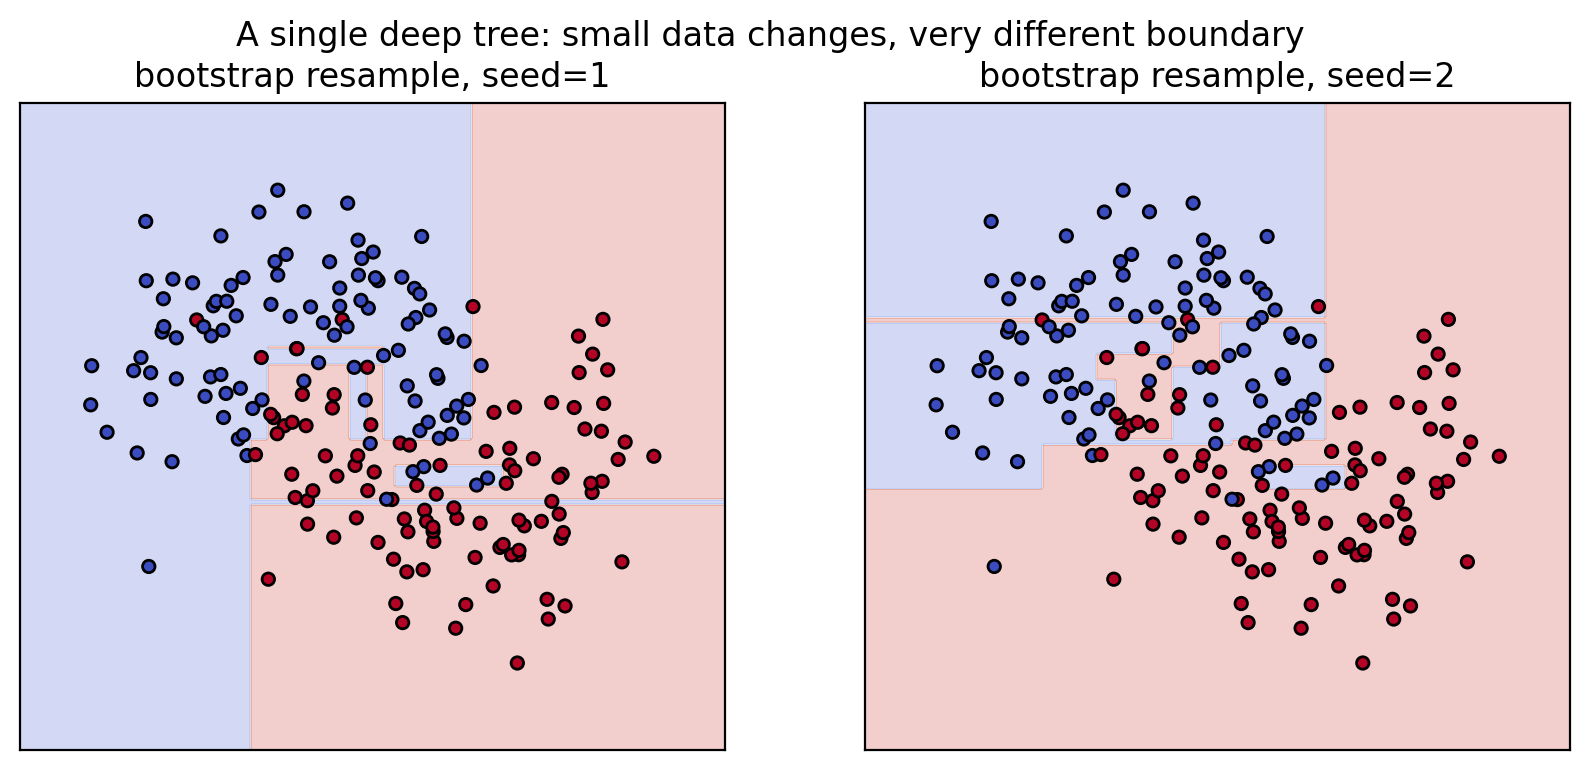

In [ ]:
_X, _y = make_moons(n_samples=200, noise=0.3, random_state=0)
_fig, _axes = plt.subplots(1, 2, figsize=(10, 4.2))
for _ax, _seed in zip(_axes, [1, 2]):
    _rng = np.random.RandomState(_seed)
    _idx = _rng.choice(len(_X), size=len(_X), replace=True)
    _tree = DecisionTreeClassifier(random_state=0).fit(_X[_idx], _y[_idx])
    _gx, _gy = np.meshgrid(
        np.linspace(_X[:, 0].min() - 0.5, _X[:, 0].max() + 0.5, 250),
        np.linspace(_X[:, 1].min() - 0.5, _X[:, 1].max() + 0.5, 250),
    )
    _Z = _tree.predict(np.c_[_gx.ravel(), _gy.ravel()]).reshape(_gx.shape)
    _ax.contourf(_gx, _gy, _Z, alpha=0.25, cmap="coolwarm")
    _ax.scatter(_X[:, 0], _X[:, 1], c=_y, cmap="coolwarm", edgecolors="k", s=20)
    _ax.set_title(f"bootstrap resample, seed={_seed}")
    _ax.set_xticks([])
    _ax.set_yticks([])
_fig.suptitle("A single deep tree: small data changes, very different boundary")
_fig

In [ ]:
mo.md(
    r"""
## Averaging kills variance

- Average $B$ predictors, each with variance $\sigma^2$, pairwise correlation $\rho$:

$$
\mathrm{Var}(\text{average}) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2
$$

- The $\frac{1}{B}$ term vanishes as $B\to\infty$
- The $\rho\sigma^2$ term does not: correlated trees put a floor on how much averaging helps
- Two ways to lower $\rho$: bootstrap the data (bagging), or also bootstrap the features (random forest)
    """
).callout(kind="info")

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003ch2 id=\"averaging-kills-variance\"\u003eAveraging kills variance\u003c/h2\u003e\n\u003cul\u003e\n\u003cli\u003eAverage \u003cmarimo-tex class=\"arithmatex\"\u003e||(B||)\u003c/marimo-tex\u003e predictors, each with variance \u003cmarimo-tex class=\"arithmatex\"\u003e||(\\sigma^2||)\u003c/marimo-tex\u003e, pairwise correlation \u003cmarimo-tex class=\"arithmatex\"\u003e||(\\rho||)\u003c/marimo-tex\u003e:\u003c/li\u003e\n\u003c/ul\u003e\n\u003cmarimo-tex class=\"arithmatex\"\u003e||[\n\\mathrm{Var}(\\text{average}) = \\rho\\sigma^2 + \\frac{1-\\rho}{B}\\sigma^2\n||]\u003c/marimo-tex\u003e\u003cul\u003e\n\u003cli\u003eThe \u003cmarimo-tex class=\"arithmatex\"\u003e||(\\frac{1}{B}||)\u003c/marimo-tex\u003e term vanishes as \u003cmarimo-tex class=\"arithmatex\"\u003e||(B\\to\\infty||)\u003c/marimo-tex\u003e\u003c/li\u003e\n\u003cli\u003eThe \u003cmarimo-tex class=\"arithmatex\"\u003e||(\\rho\\sigma^2||)\u003c/marimo-tex\u003e term does not: correlated trees put a floor on how much averaging helps\u003c/li\u003e\n\u003cli\u003eTwo ways to lower \u003cmarimo-tex class=\"arithmatex\"\u003e||(\\rho||)\u003c/marimo-tex\u003e: bootstrap the data (bagging), or also bootstrap the features (random forest)\u003c/li\u003e\n\u003c/ul\u003e\u003c/span\u003e"' data-kind='"info"'>

## Bagging (Breiman, 1996)

- Bootstrap: draw $N$ samples **with replacement** from the $N$-sample training set
- Fit one deep tree per bootstrap sample, $B$ trees total
- Predict: majority vote (classification) or mean (regression)
- Each bootstrap leaves out $\approx 1/e \approx 36.8\%$ of points
    - Free validation set: **out-of-bag (OOB) error**

In [ ]:
def fit_bagging(X, y, n_trees, rng, max_features=None):
    """Bootstrap `n_trees` deep trees. Passing `max_features` turns this
    into the random-forest variant further down."""
    n = len(X)
    trees = []
    for _ in range(n_trees):
        idx = rng.randint(0, n, size=n)
        tree = DecisionTreeClassifier(
            max_features=max_features, random_state=rng.randint(1_000_000)
        )
        tree.fit(X[idx], y[idx])
        trees.append(tree)
    return trees

def predict_vote(trees, X):
    votes = np.stack([t.predict(X) for t in trees])
    return (votes.mean(axis=0) >= 0.5).astype(int)

### Bagging - practical notes

- Helps most for **unstable** learners (deep trees); barely moves the needle for stable ones (e.g. 1-NN)
- Trees only depend on their own bootstrap sample: fits in parallel
- Does not reduce bias - still limited by how well one tree can fit

In [ ]:
n_trees_bag = mo.ui.slider(
    start=1, stop=60, step=1, value=1, show_value=True, label="number of trees"
)


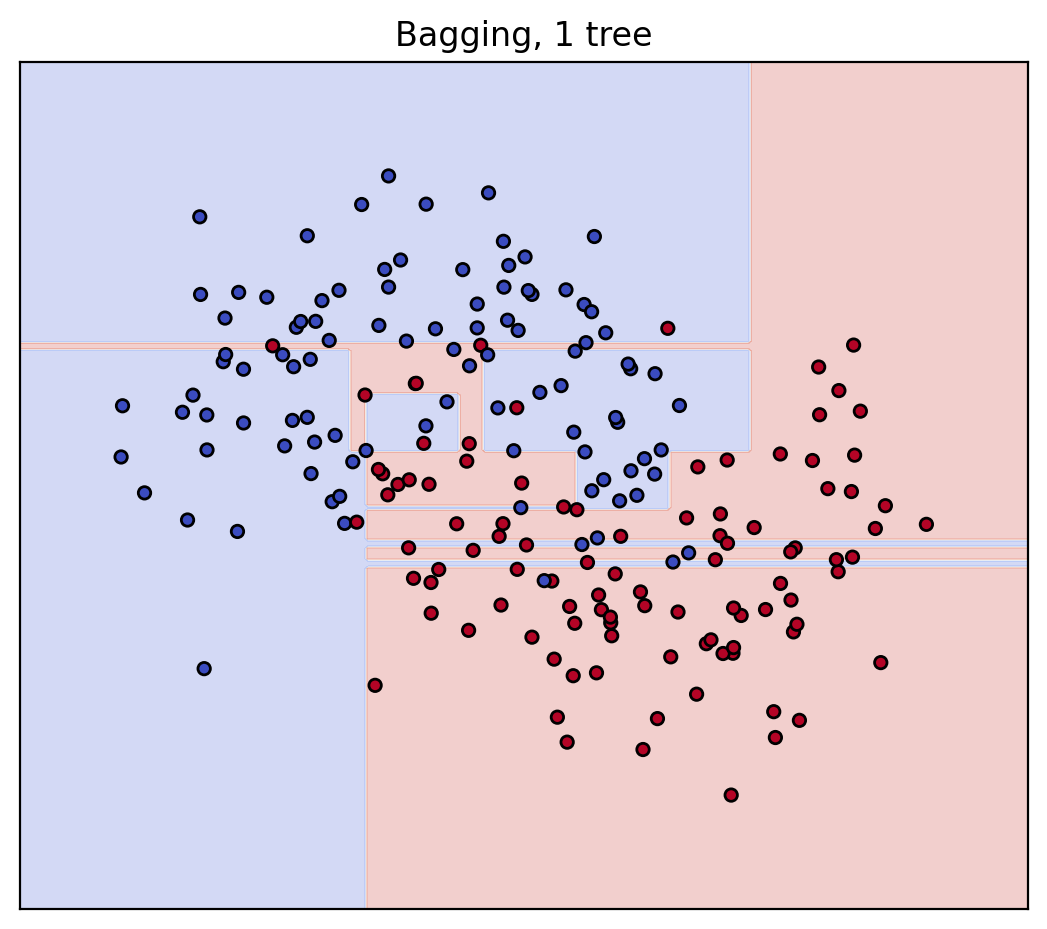

In [ ]:
_X, _y = make_moons(n_samples=200, noise=0.3, random_state=0)
_rng = np.random.RandomState(0)
_trees = fit_bagging(_X, _y, n_trees_bag.value, _rng)
_gx, _gy = np.meshgrid(
    np.linspace(_X[:, 0].min() - 0.5, _X[:, 0].max() + 0.5, 250),
    np.linspace(_X[:, 1].min() - 0.5, _X[:, 1].max() + 0.5, 250),
)
_Z = predict_vote(_trees, np.c_[_gx.ravel(), _gy.ravel()]).reshape(_gx.shape)
_fig, _ax = plt.subplots(figsize=(6.5, 5.5))
_ax.contourf(_gx, _gy, _Z, alpha=0.25, cmap="coolwarm")
_ax.scatter(_X[:, 0], _X[:, 1], c=_y, cmap="coolwarm", edgecolors="k", s=20)
_n = n_trees_bag.value
_ax.set_title(f"Bagging, {_n} tree{'s' if _n != 1 else ''}")
_ax.set_xticks([])
_ax.set_yticks([])
mo.vstack([n_trees_bag, _fig])

## Random forests (Breiman, 2001)

- Bagging + **one extra source of randomness**: at each split, consider only $m$ of the $d$ features
    - Classification: $m \approx \sqrt{d}$. Regression: $m \approx d/3$
- Why: bagging alone still lets the same strong feature dominate every tree - trees stay correlated
- Restricting the feature subset decorrelates the trees, lowering $\rho$ in the variance formula above

In [ ]:
n_trees_rf = mo.ui.slider(
    start=1, stop=60, step=1, value=20, show_value=True, label="number of trees"
)
m_rf = mo.ui.slider(
    start=1, stop=2, step=1, value=2, show_value=True, label="features per split (m)"
)


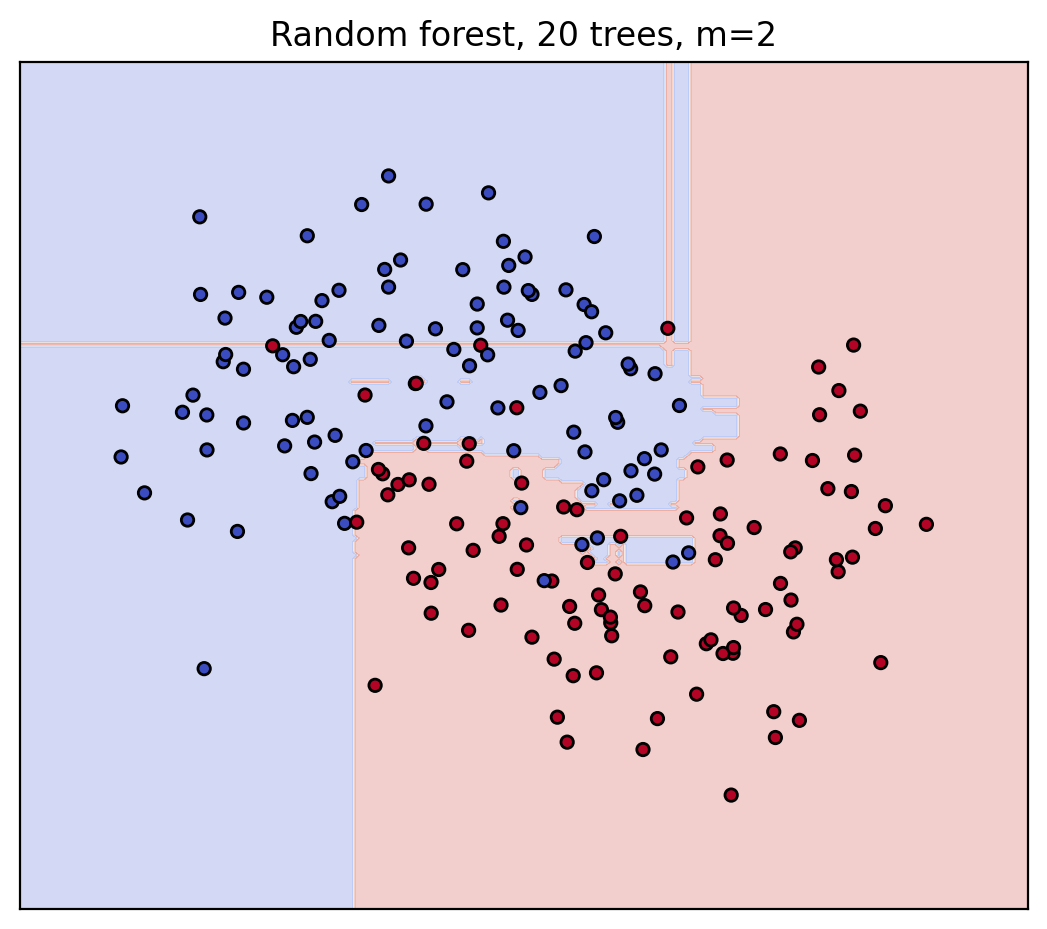

In [ ]:
_X, _y = make_moons(n_samples=200, noise=0.3, random_state=0)
_rng = np.random.RandomState(0)
_trees = fit_bagging(_X, _y, n_trees_rf.value, _rng, max_features=m_rf.value)
_gx, _gy = np.meshgrid(
    np.linspace(_X[:, 0].min() - 0.5, _X[:, 0].max() + 0.5, 250),
    np.linspace(_X[:, 1].min() - 0.5, _X[:, 1].max() + 0.5, 250),
)
_Z = predict_vote(_trees, np.c_[_gx.ravel(), _gy.ravel()]).reshape(_gx.shape)
_fig, _ax = plt.subplots(figsize=(6.5, 5.5))
_ax.contourf(_gx, _gy, _Z, alpha=0.25, cmap="coolwarm")
_ax.scatter(_X[:, 0], _X[:, 1], c=_y, cmap="coolwarm", edgecolors="k", s=20)
_ax.set_title(f"Random forest, {n_trees_rf.value} trees, m={m_rf.value}")
_ax.set_xticks([])
_ax.set_yticks([])
mo.vstack([n_trees_rf, m_rf, _fig])

In [ ]:
mo.md(
    r"""
**Bagging vs. random forest, in one line:** bagging derandomizes the *data*;
random forest also derandomizes the *features*. With only 2 raw features
here, $m=1$ vs. $m=2$ (drag above) already is the whole story - decorrelating
trees is the point, not a side effect.
    """
).callout(kind="success")

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cstrong\u003eBagging vs. random forest, in one line:\u003c/strong\u003e bagging derandomizes the \u003cem\u003edata\u003c/em\u003e;\nrandom forest also derandomizes the \u003cem\u003efeatures\u003c/em\u003e. With only 2 raw features\nhere, \u003cmarimo-tex class=\"arithmatex\"\u003e||(m=1||)\u003c/marimo-tex\u003e vs. \u003cmarimo-tex class=\"arithmatex\"\u003e||(m=2||)\u003c/marimo-tex\u003e (drag above) already is the whole story - decorrelating\ntrees is the point, not a side effect.\u003c/span\u003e\u003c/span\u003e"' data-kind='"success"'>

## Boosting

- Bagging: $B$ trees fit **independently**, in parallel
- Boosting: fit trees **sequentially** - each one focused on the previous ensemble's mistakes
- Weak learners combined into a strong one - here: decision stumps (depth-1 trees)

## Deriving AdaBoost from the exponential loss

- Labels $y_i \in \{-1, +1\}$. Ensemble so far: $F_{m-1}(x) = \sum_{k=1}^{m-1} \alpha_k h_k(x)$
- Add one term, greedily, minimizing the exponential loss:

$$
(\alpha_m, h_m) = \arg\min_{\alpha, h} \sum_{i=1}^N \exp\big(-y_i (F_{m-1}(x_i) + \alpha\, h(x_i))\big)
$$

- Write $w_i^{(m)} = \exp(-y_i F_{m-1}(x_i))$ (fixed at step $m$, it only depends on the past). The objective becomes

$$
\sum_i w_i^{(m)} \exp(-\alpha y_i h(x_i))
$$

### Solving for $h_m$ and $\alpha_m$

- Split the sum into correct / wrong predictions. For any fixed $\alpha>0$, it is minimized by the $h$ minimizing the **weighted error**

$$
\varepsilon_m = \frac{\sum_i w_i^{(m)} \mathbb{1}[h(x_i)\neq y_i]}{\sum_i w_i^{(m)}}
$$

- Differentiate w.r.t. $\alpha$, set to zero:

$$
\alpha_m = \frac{1}{2}\ln\frac{1-\varepsilon_m}{\varepsilon_m}
$$

- Weight update, $w_i^{(m+1)} = w_i^{(m)} e^{-\alpha_m y_i h_m(x_i)}$: misclassified points reweighted up by $e^{\alpha_m}$, correct ones down by $e^{-\alpha_m}$

### The AdaBoost algorithm (Freund & Schapire, 1997)

- Initialize $w_i^{(1)} = 1/N$
- For $m = 1, \dots, M$:
    - Fit $h_m$ on the weighted data (minimize $\varepsilon_m$)
    - $\alpha_m = \frac12 \ln\frac{1-\varepsilon_m}{\varepsilon_m}$
    - Reweight, then renormalize so weights sum to 1
- Output: $F(x) = \mathrm{sign}\left(\sum_m \alpha_m h_m(x)\right)$

In [ ]:
def fit_adaboost(X, y, n_rounds):
    """Decision-stump AdaBoost. Labels y in {-1, +1}."""
    n = len(X)
    w = np.full(n, 1.0 / n)
    stumps, alphas = [], []
    for _ in range(n_rounds):
        stump = DecisionTreeClassifier(max_depth=1)
        stump.fit(X, y, sample_weight=w)
        pred = stump.predict(X)
        err = np.sum(w * (pred != y)) / np.sum(w)
        err = np.clip(err, 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - err) / err)
        w = w * np.exp(-alpha * y * pred)
        w = w / w.sum()
        stumps.append(stump)
        alphas.append(alpha)
    return stumps, alphas

def predict_adaboost(stumps, alphas, X):
    agg = sum(a * s.predict(X) for s, a in zip(stumps, alphas))
    return np.sign(agg)

### Does more rounds mean overfitting?

- Training error keeps dropping as $M$ grows - does test error follow it back up?
- Below: a noisy Two Moons problem, train and test error against $M$, on the **same** plot

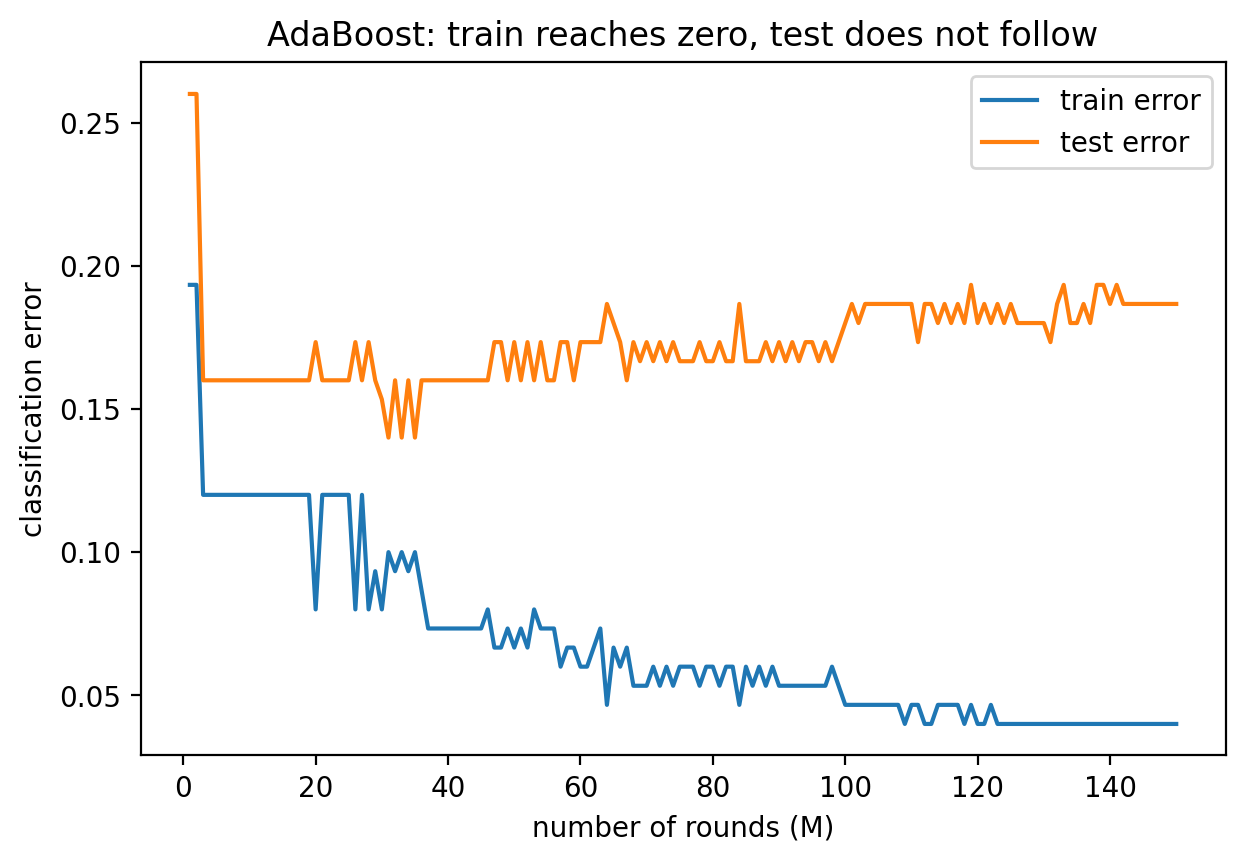

In [ ]:
_X, _y01 = make_moons(n_samples=300, noise=0.35, random_state=7)
_y = np.where(_y01 == 0, -1, 1)
_X_train, _X_test, _y_train, _y_test = train_test_split(
    _X, _y, test_size=0.5, random_state=7
)

_n_rounds_max = 150
_stumps, _alphas = fit_adaboost(_X_train, _y_train, _n_rounds_max)

# Vectorized: predict once per stump, then take a running (cumulative)
# weighted sum over rounds - O(M) instead of refitting/repredicting the
# full ensemble at every prefix length.
_train_preds = np.array([s.predict(_X_train) for s in _stumps])
_test_preds = np.array([s.predict(_X_test) for s in _stumps])
_alphas_arr = np.array(_alphas)[:, None]

_train_cumsum = np.cumsum(_alphas_arr * _train_preds, axis=0)
_test_cumsum = np.cumsum(_alphas_arr * _test_preds, axis=0)

_train_err = np.mean(np.sign(_train_cumsum) != _y_train[None, :], axis=1)
_test_err = np.mean(np.sign(_test_cumsum) != _y_test[None, :], axis=1)

_fig, _ax = plt.subplots(figsize=(7, 4.5))
_ax.plot(range(1, _n_rounds_max + 1), _train_err, label="train error")
_ax.plot(range(1, _n_rounds_max + 1), _test_err, label="test error")
_ax.set_xlabel("number of rounds (M)")
_ax.set_ylabel("classification error")
_ax.set_title("AdaBoost: train reaches zero, test does not follow")
_ax.legend()
_fig

In [ ]:
mo.md(
    r"""
**Read the gap, not just the training curve.** Training error can reach
zero while test error plateaus well above it - that gap is the real
signal, and it is invisible if you only plot training accuracy. AdaBoost
with stumps is empirically more resistant to runaway overfitting than
this picture might suggest (margin-based arguments explain why), but the
gap does not close simply by adding more rounds.
    """
).callout(kind="warn")

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cstrong\u003eRead the gap, not just the training curve.\u003c/strong\u003e Training error can reach\nzero while test error plateaus well above it - that gap is the real\nsignal, and it is invisible if you only plot training accuracy. AdaBoost\nwith stumps is empirically more resistant to runaway overfitting than\nthis picture might suggest (margin-based arguments explain why), but the\ngap does not close simply by adding more rounds.\u003c/span\u003e\u003c/span\u003e"' data-kind='"warn"'>

## Outlook: gradient boosting

- AdaBoost = forward stagewise fitting, specifically **of the exponential loss**
- Gradient boosting: same recipe, any differentiable loss - fit each new tree to (minus) the loss gradient of the current ensemble
- AdaBoost is recovered as the special case of the exponential loss
- In practice: XGBoost, LightGBM, CatBoost - not covered here in depth

In [ ]:
mo.mermaid(
    """
graph TD
    P0[◀ Kernel methods]:::pv
    recap[Recap: a single tree is unstable]
    bag[Bagging: bootstrap the data]
    rf[Random forest: also bootstrap the features]
    boost[Boosting: sequential, reweight mistakes]
    ada[AdaBoost: derived from the exponential loss]
    recap --> bag --> rf
    recap --> boost --> ada
    P0 -.->|end of the supervised classifiers block| recap
    rf -.->|correlation sets a floor on variance| var[why bagging alone is not enough]
    ada -.->|same recipe, any loss| N0[Next — Data transformations I ▶]:::nx
    classDef pv fill:#eeeeee,stroke:#999999,color:#555555;
    classDef nx fill:#e8f0ff,stroke:#3377aa,color:#224466;
"""
)

<marimo-mermaid data-diagram='"\ngraph TD\n P0[◀ Kernel methods]:::pv\n recap[Recap: a single tree is unstable]\n bag[Bagging: bootstrap the data]\n rf[Random forest: also bootstrap the features]\n boost[Boosting: sequential, reweight mistakes]\n ada[AdaBoost: derived from the exponential loss]\n recap --\u003e bag --\u003e rf\n recap --\u003e boost --\u003e ada\n P0 -.-\u003e|end of the supervised classifiers block| recap\n rf -.-\u003e|correlation sets a floor on variance| var[why bagging alone is not enough]\n ada -.-\u003e|same recipe, any loss| N0[Next — Data transformations I ▶]:::nx\n classDef pv fill:#eeeeee,stroke:#999999,color:#555555;\n classDef nx fill:#e8f0ff,stroke:#3377aa,color:#224466;\n"'>